In [1]:
import pandas as pd
import numpy as np
import matplotlib.pyplot as plt
import matplotlib.ticker as mtick
import seaborn as sns
from pathlib import Path

RAW_DATA_DIR = Path("../data/raw")

# Plot style parameters
sns.set_theme(style="whitegrid", palette="muted")
plt.rcParams["figure.figsize"] = (12, 5)
plt.rcParams["figure.dpi"] = 120

In [2]:
FRED = pd.read_csv(RAW_DATA_DIR / "fred.csv", index_col="date",parse_dates=True)
print(FRED.tail())

            default_rate_total  default_rate_credit_card  default_rate_other
date                                                                        
2010-10-01                3.63                      4.14                3.07
2011-01-01                3.43                      3.82                2.99
2011-04-01                3.27                      3.65                2.88
2011-07-01                3.13                      3.45                2.77
2011-10-01                3.07                      3.25                2.90


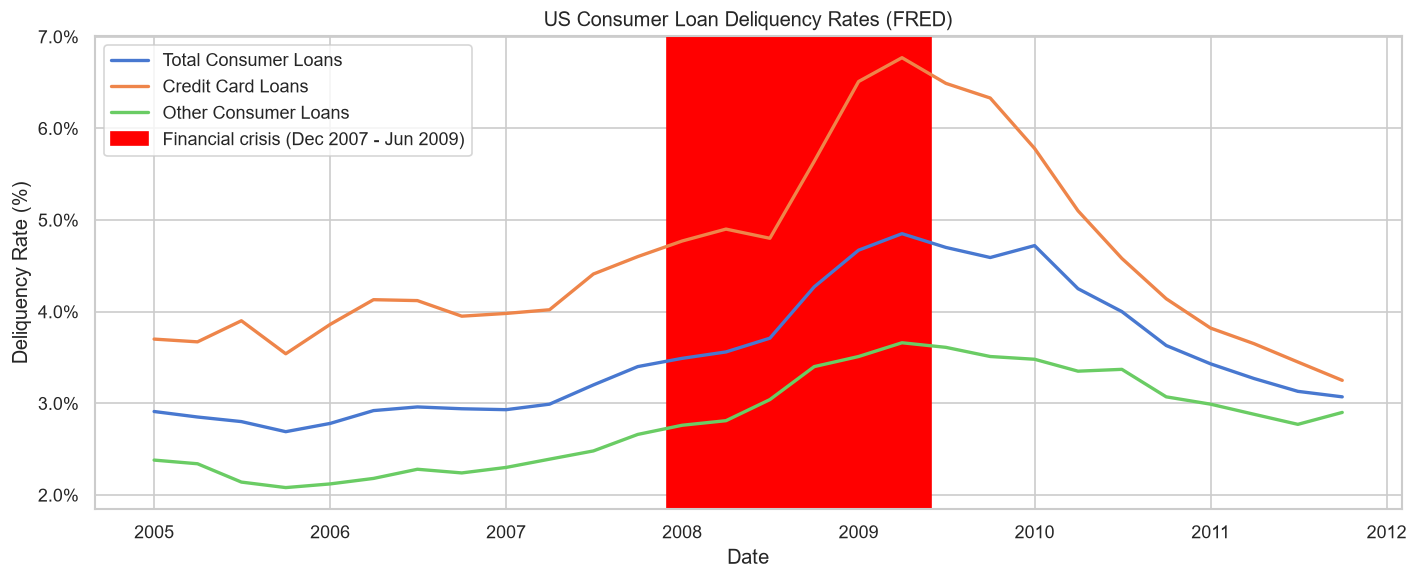

In [4]:
fix, ax = plt.subplots()

labels = {
    "default_rate_total": "Total Consumer Loans",
    "default_rate_credit_card": "Credit Card Loans",
    "default_rate_other": "Other Consumer Loans"
}

for column, label in labels.items():
    ax.plot(FRED.index, FRED[column], label=label, linewidth=2)

# Marking the US's 2008 financial crisis
ax.axvspan(
    pd.Timestamp("2007-12-01"),
    pd.Timestamp("2009-06-01"),
    color="red",
    label="Financial crisis (Dec 2007 - Jun 2009)"
)

ax.yaxis.set_major_formatter(mtick.PercentFormatter())
ax.set_title("US Consumer Loan Deliquency Rates (FRED)")
ax.set_xlabel("Date")
ax.set_ylabel("Deliquency Rate (%)")
ax.legend()
plt.tight_layout()
plt.savefig("../results/fred_series.png")
plt.show()

Kaggle aggregate default rate: 6.68%


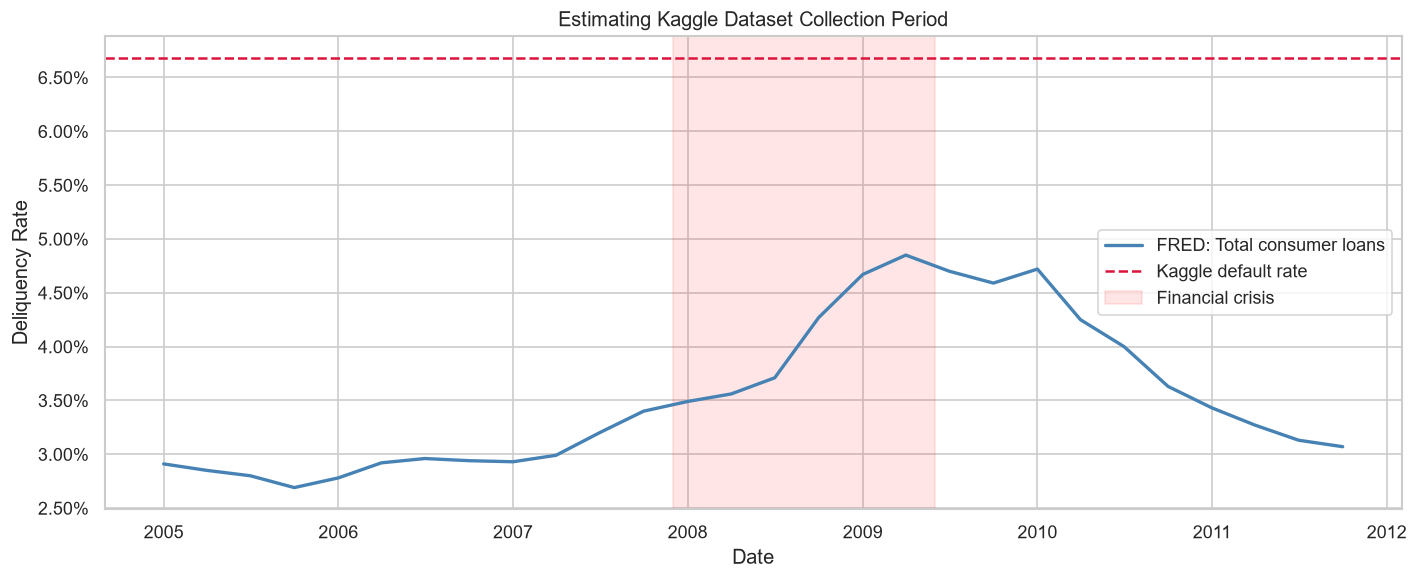

Closest FRED period to Kaggle default rate: 2009-04-01
FRED value at that period :4.85


In [6]:
KAGGLE = pd.read_csv(RAW_DATA_DIR / "cs-training.csv")

kaggle_default_rate = KAGGLE["SeriousDlqin2yrs"].mean()*100

print(f"Kaggle aggregate default rate: {kaggle_default_rate:.2f}%")

fig, ax = plt.subplots()

ax.plot(
    FRED.index,
    FRED["default_rate_total"],
    label="FRED: Total consumer loans",
    linewidth=2,
    color="steelblue"
)

ax.axhline(
    y=kaggle_default_rate,
    color="crimson",
    linestyle="--",
    label="Kaggle default rate"
)

ax.axvspan(
    pd.Timestamp("2007-12-01"),
    pd.Timestamp("2009-06-01"),
    alpha=0.1,
    color="red",
    label="Financial crisis"
)

ax.yaxis.set_major_formatter(mtick.PercentFormatter())
ax.set_title("Estimating Kaggle Dataset Collection Period")
ax.set_xlabel("Date")
ax.set_ylabel("Deliquency Rate")
ax.legend()

plt.tight_layout()
plt.savefig("../results/fred_vs_kaggle.png")
plt.show()

FRED["distance"] = (FRED["default_rate_total"] - kaggle_default_rate).abs()
closest = FRED["distance"].idxmin()
print(f"Closest FRED period to Kaggle default rate: {closest.date()}")
print(f"FRED value at that period :{FRED.loc[closest, "default_rate_total"]}")
FRED=FRED.drop(columns=["distance"])

In [7]:
COLUMN_RENAME = {
    "SeriousDlqin2yrs":                     "target",
    "RevolvingUtilizationOfUnsecuredLines":  "revolving_utilization",
    "age":                                   "age",
    "NumberOfTime30-59DaysPastDueNotWorse":  "past_due_30_59",
    "DebtRatio":                             "debt_ratio",
    "MonthlyIncome":                         "monthly_income",
    "NumberOfOpenCreditLinesAndLoans":       "open_credit_lines",
    "NumberOfTimes90DaysLate":              "times_90_days_late",
    "NumberRealEstateLoansOrLines":          "real_estate_loans",
    "NumberOfTime60-89DaysPastDueNotWorse":  "past_due_60_89",
    "NumberOfDependents":                    "dependents",
}

KAGGLE = KAGGLE.drop(columns=["Unnamed: 0"]).rename(columns=COLUMN_RENAME)
print(KAGGLE.shape)
print(KAGGLE.head())

(150000, 11)
   target  revolving_utilization  age  past_due_30_59  debt_ratio  \
0       1               0.766127   45               2    0.802982   
1       0               0.957151   40               0    0.121876   
2       0               0.658180   38               1    0.085113   
3       0               0.233810   30               0    0.036050   
4       0               0.907239   49               1    0.024926   

   monthly_income  open_credit_lines  times_90_days_late  real_estate_loans  \
0          9120.0                 13                   0                  6   
1          2600.0                  4                   0                  0   
2          3042.0                  2                   1                  0   
3          3300.0                  5                   0                  0   
4         63588.0                  7                   0                  1   

   past_due_60_89  dependents  
0               0         2.0  
1               0         1.0  
2

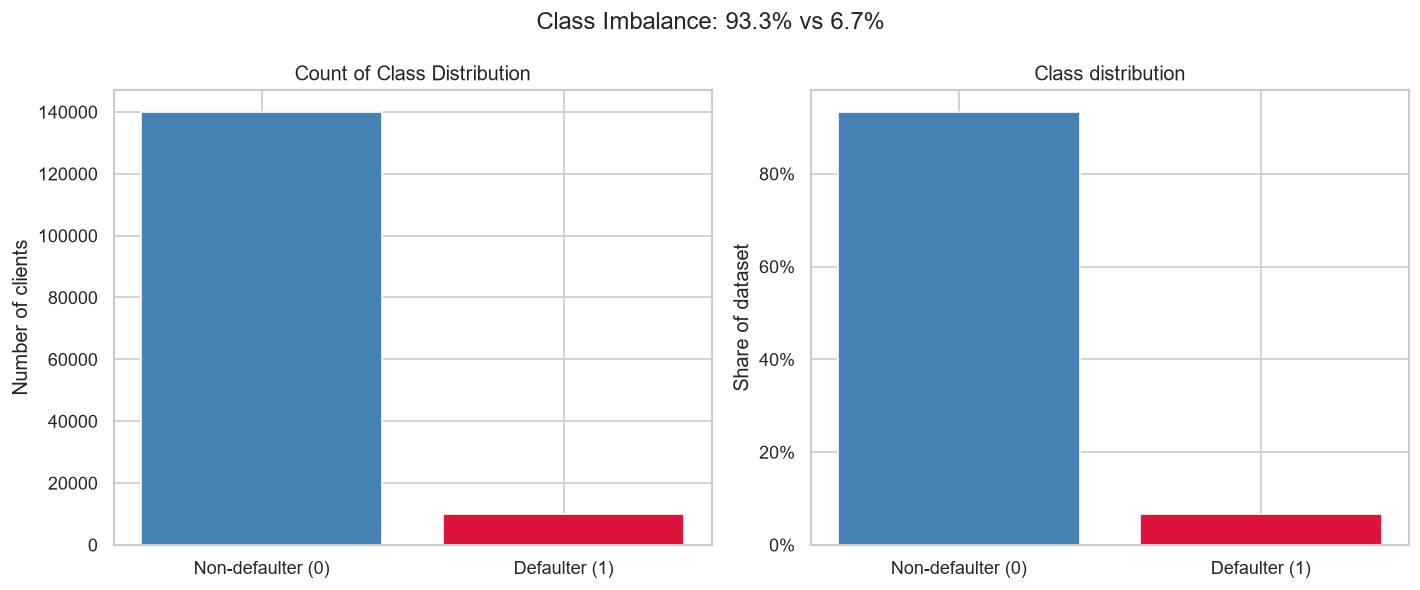

In [12]:
class_counts = KAGGLE["target"].value_counts()
class_pct = KAGGLE["target"].value_counts(normalize=True) *100
fig, axes = plt.subplots(1, 2)

axes[0].bar(
    ["Non-defaulter (0)", "Defaulter (1)"],
    class_counts.values,
    color=["steelblue", "crimson"]
)

axes[1].bar(
    ["Non-defaulter (0)", "Defaulter (1)"],
    class_pct.values,
    color=["steelblue", "crimson"]
)

axes[0].set_title("Count of Class Distribution")
axes[0].set_ylabel("Number of clients")

axes[1].yaxis.set_major_formatter(mtick.PercentFormatter())
axes[1].set_title("Class distribution")
axes[1].set_ylabel("Share of dataset")

plt.suptitle("Class Imbalance: 93.3% vs 6.7%")
plt.tight_layout()
plt.savefig("../results/class_imbalance.png")
plt.show()

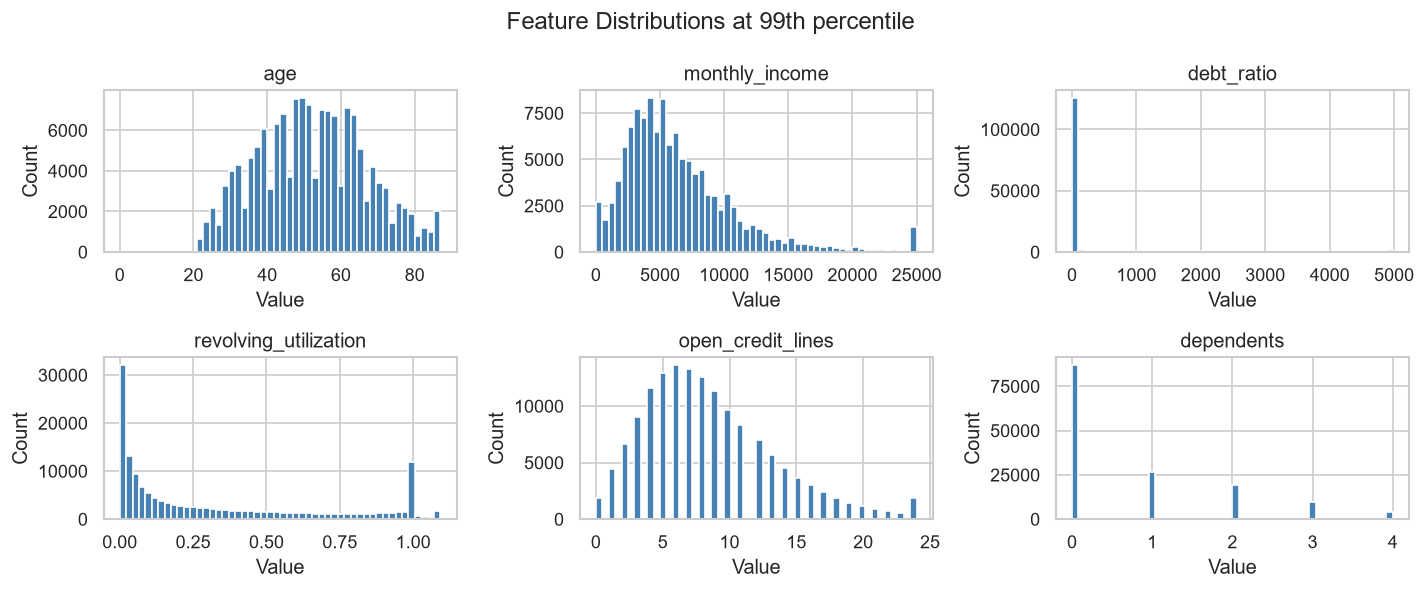

In [13]:
features = [
    "age", "monthly_income", "debt_ratio", "revolving_utilization", "open_credit_lines", "dependents"
]

fig, axes = plt.subplots(2, 3)
axes = axes.flatten()

for i, feature in enumerate(features):
    data = KAGGLE[feature].clip(upper=KAGGLE[feature].quantile(0.99))
    axes[i].hist(data, bins=50, color="steelblue", edgecolor="white")
    axes[i].set_title(feature)
    axes[i].set_xlabel("Value")
    axes[i].set_ylabel("Count")

plt.suptitle("Feature Distributions at 99th percentile")
plt.tight_layout()
plt.savefig("../results/feature_distributions.png")
plt.show()

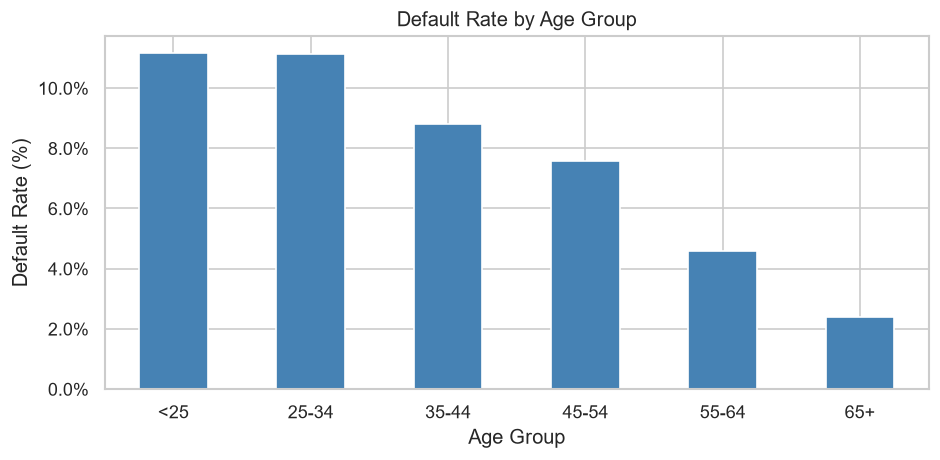

In [14]:
KAGGLE["age_group"] = pd.cut(
    KAGGLE["age"],
    bins=[0, 25, 35, 45, 55, 65, 100],
    labels=["<25", "25-34", "35-44", "45-54", "55-64", "65+"]
)

default_by_age = KAGGLE.groupby("age_group", observed=True)["target"].mean() *100

fig, ax = plt.subplots(figsize=(8,4))
default_by_age.plot(kind="bar", ax=ax, color="steelblue", edgecolor="white")
ax.yaxis.set_major_formatter(mtick.PercentFormatter())
ax.set_title("Default Rate by Age Group")
ax.set_xlabel("Age Group")
ax.set_ylabel("Default Rate (%)")
ax.tick_params(axis="x", rotation=0)
plt.tight_layout()
plt.savefig("../results/default_by_age.png")
plt.show()

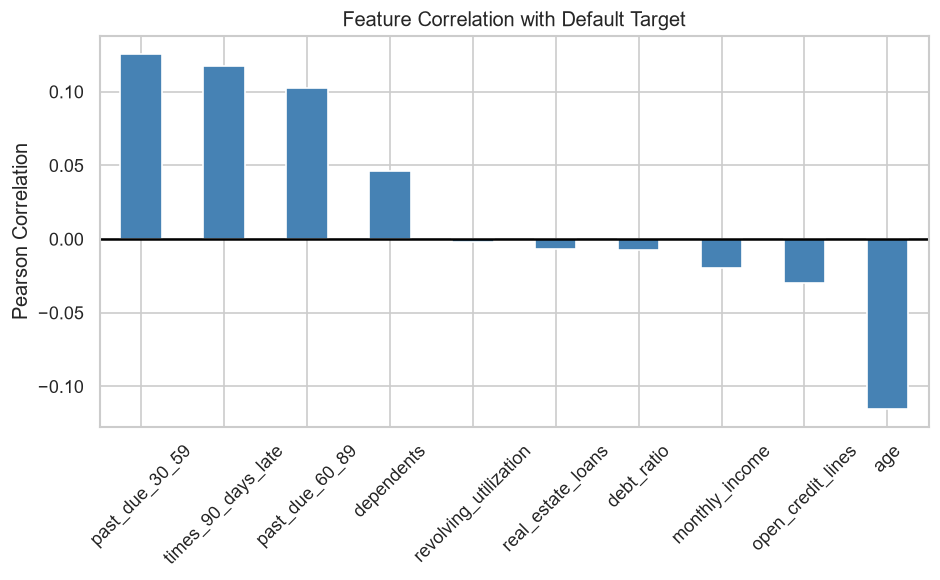

Top 5 features correlated with default:
past_due_30_59           0.125587
times_90_days_late       0.117175
past_due_60_89           0.102261
dependents               0.046048
revolving_utilization   -0.001802
Name: target, dtype: float64


In [16]:
numeric_cols = KAGGLE.select_dtypes(include=np.number).drop(columns=["target"])
corr_with_target = (
    KAGGLE[numeric_cols.columns.tolist() + ["target"]].corr()["target"].drop("target").sort_values(ascending=False)
)

fig, ax = plt.subplots(figsize=(8, 5))
corr_with_target.plot(kind="bar", ax=ax, color="steelblue", edgecolor="white")
ax.axhline(0, color="black")
ax.set_title("Feature Correlation with Default Target")
ax.set_ylabel("Pearson Correlation")
ax.tick_params(axis="x", rotation=45)
plt.tight_layout()
plt.savefig("../results/feature_correlations.png")
plt.show()

print("Top 5 features correlated with default:")
print(corr_with_target.head())


In [18]:
print("=== Dataset Summary ===")
print(f"Total clients      : {len(KAGGLE):,}")
print(f"Default rate       : {KAGGLE['target'].mean():.2%}")
print(f"Missing income     : {KAGGLE['monthly_income'].isna().sum():,} ({KAGGLE['monthly_income'].isna().mean():.1%})")
print(f"Missing dependents : {KAGGLE['dependents'].isna().sum():,} ({KAGGLE['dependents'].isna().mean():.1%})")
print(f"Top predictors (correlation with target):")
print(corr_with_target.head().to_string())

=== Dataset Summary ===
Total clients      : 150,000
Default rate       : 6.68%
Missing income     : 29,731 (19.8%)
Missing dependents : 3,924 (2.6%)
Top predictors (correlation with target):
past_due_30_59           0.125587
times_90_days_late       0.117175
past_due_60_89           0.102261
dependents               0.046048
revolving_utilization   -0.001802
